In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/sample_submission.csv
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/83caa8a85e03606cf57e49147d7ac569.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/7550347fa2bb96c2354a3716dfa3a69c.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/74b23792db329cff5843e36efb8aa65a.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/94568a546be103177cb582d3e91cd2d8.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/6da36354fc904b63bc03eb3884e0c35c.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/5b3620a56668010877cfafa9322e18b5.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/5157d5c9b1f0004b29310652ea54e825.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/74897408dcbd69ef7c76cbbbbeb722d6.dicom
/kaggle/input/vi

In [10]:
import os
import random
import pandas as pd
import numpy as np
import pydicom
import cv2
from tqdm import tqdm


In [11]:
# Load training CSV
df = pd.read_csv('/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv')

# Get unique image IDs
unique_images = df['image_id'].unique()

# Randomly select 1500 images
selected_images = random.sample(list(unique_images), 1500)

print("Selected images:", len(selected_images))


Selected images: 1500


In [12]:
os.makedirs("train_jpg", exist_ok=True)


In [13]:
input_folder = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"

for image_id in tqdm(selected_images):
    
    dicom_path = os.path.join(input_folder, image_id + ".dicom")
    
    # Read DICOM file
    dicom = pydicom.dcmread(dicom_path)
    image = dicom.pixel_array
    
    # Convert to 8-bit format (required for JPG)
    image = image.astype(np.float32)
    image = (image - image.min()) / (image.max() - image.min())
    image = (image * 255).astype(np.uint8)
    
    # Save as JPG
    output_path = os.path.join("train_jpg", image_id + ".jpg")
    cv2.imwrite(output_path, image)

print("Conversion completed successfully")

100%|██████████| 1500/1500 [32:09<00:00,  1.29s/it] 

Conversion completed successfully


In [14]:
import os

jpg_folder = "/kaggle/working/train_jpg"

print("Total JPG files:", len(os.listdir(jpg_folder)))


Total JPG files: 1500


In [15]:
print("Selected images count:", len(selected_images))


Selected images count: 1500


In [16]:
import os

converted_files = os.listdir("/kaggle/working/train_jpg")
converted_ids = [f.replace(".jpg", "") for f in converted_files]

missing = set(selected_images) - set(converted_ids)

print("Missing images count:", len(missing))


Missing images count: 0


In [17]:
import os

source_folder = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"

existing = []
not_existing = []

for image_id in selected_images:
    path = os.path.join(source_folder, image_id + ".dicom")
    if os.path.exists(path):
        existing.append(image_id)
    else:
        not_existing.append(image_id)

print("Existing DICOM files:", len(existing))
print("Missing DICOM files:", len(not_existing))


Existing DICOM files: 1500
Missing DICOM files: 0


In [18]:
import os

converted_files = os.listdir("/kaggle/working/train_jpg")
converted_ids = [f.replace(".jpg", "") for f in converted_files]

missing_images = list(set(selected_images) - set(converted_ids))

print("Images left to convert:", len(missing_images))


Images left to convert: 0


In [19]:
import pydicom
import cv2
import numpy as np
from tqdm import tqdm
import os

input_folder = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"

for image_id in tqdm(missing_images):
    
    dicom_path = os.path.join(input_folder, image_id + ".dicom")
    
    dicom = pydicom.dcmread(dicom_path)
    image = dicom.pixel_array
    
    image = image.astype(np.float32)
    image = (image - image.min()) / (image.max() - image.min())
    image = (image * 255).astype(np.uint8)
    
    output_path = os.path.join("/kaggle/working/train_jpg", image_id + ".jpg")
    cv2.imwrite(output_path, image)

print("Remaining images converted successfully")


0it [00:00, ?it/s]

Remaining images converted successfully


In [20]:
print("Final JPG count:", len(os.listdir("/kaggle/working/train_jpg")))


Final JPG count: 1500


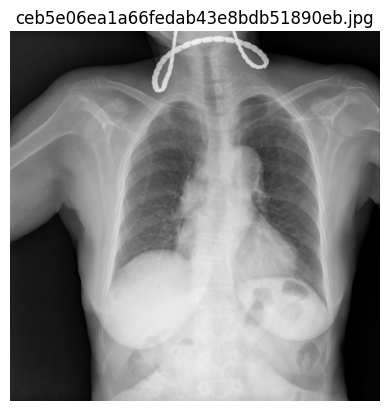

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

sample_image = os.listdir(jpg_folder)[0]
img = Image.open(os.path.join(jpg_folder, sample_image))

plt.imshow(img, cmap='gray')
plt.title(sample_image)
plt.axis('off')
plt.show()


Files inside folder: ['ceb5e06ea1a66fedab43e8bdb51890eb.jpg', 'c14cbdbdd9e48f814b8e8991b4cd58d1.jpg', 'c92a0bd2d3c781a82946934351821e9a.jpg', 'e2b2574690d765edd3eff55196b535ba.jpg', '2f4f119515e7a3c9b76c704caf75976f.jpg']
Opening: /kaggle/working/train_jpg/ceb5e06ea1a66fedab43e8bdb51890eb.jpg


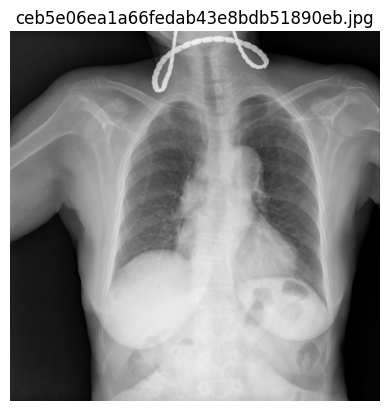

In [22]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Step 1: Define folder
jpg_folder = "/kaggle/working/train_jpg"

# Step 2: List only image files
files = os.listdir(jpg_folder)

print("Files inside folder:", files[:5])

# Step 3: Pick first image file
sample_image = files[0]

# Step 4: Create full image path
img_path = os.path.join(jpg_folder, sample_image)

print("Opening:", img_path)

# Step 5: Open image
img = Image.open(img_path)

# Step 6: Display image
plt.imshow(img, cmap='gray')
plt.title(sample_image)
plt.axis('off')
plt.show()


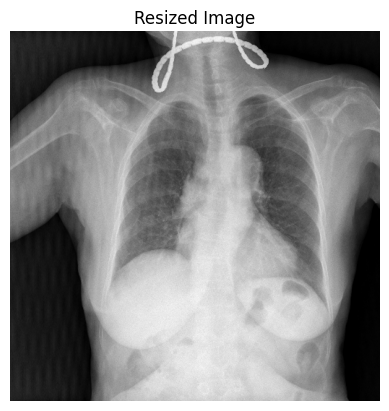

In [23]:
import cv2
import numpy as np

# Convert PIL image to numpy array
img_np = np.array(img)

# Resize to 512x512
resized = cv2.resize(img_np, (512, 512))

plt.imshow(resized, cmap='gray')
plt.title("Resized Image")
plt.axis('off')
plt.show()


In [24]:
normalized = resized / 255.0

print("Min value:", normalized.min())
print("Max value:", normalized.max())


Min value: 0.0
Max value: 0.9921568627450981


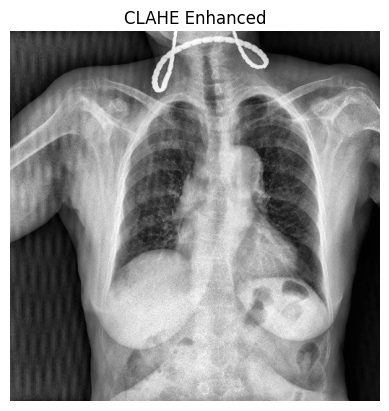

In [25]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(resized.astype(np.uint8))

plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE Enhanced")
plt.axis('off')
plt.show()


In [26]:
original_height, original_width = img_np.shape[:2]

print("Original Size:", original_width, original_height)


Original Size: 3000 3000


In [27]:
new_width = 512
new_height = 512


In [28]:
scale_x = new_width / original_width
scale_y = new_height / original_height

print("Scale X:", scale_x)
print("Scale Y:", scale_y)


Scale X: 0.17066666666666666
Scale Y: 0.17066666666666666


In [29]:
image_id = sample_image.split('.')[0]  # remove .jpg

boxes = df[(df['image_id'] == image_id) & (df['x_min'].notna())]


boxes.head()


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
3961,ceb5e06ea1a66fedab43e8bdb51890eb,Aortic enlargement,0,R16,1787.0,890.0,2102.0,1405.0
10222,ceb5e06ea1a66fedab43e8bdb51890eb,Aortic enlargement,0,R17,1631.0,921.0,2122.0,1400.0
43554,ceb5e06ea1a66fedab43e8bdb51890eb,Nodule/Mass,8,R16,1015.0,1295.0,1109.0,1400.0
66009,ceb5e06ea1a66fedab43e8bdb51890eb,Aortic enlargement,0,R13,1498.0,916.0,2065.0,1295.0


In [30]:
scaled_boxes = boxes.copy()

scaled_boxes['x_min'] = boxes['x_min'] * scale_x
scaled_boxes['x_max'] = boxes['x_max'] * scale_x
scaled_boxes['y_min'] = boxes['y_min'] * scale_y
scaled_boxes['y_max'] = boxes['y_max'] * scale_y

scaled_boxes.head()


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
3961,ceb5e06ea1a66fedab43e8bdb51890eb,Aortic enlargement,0,R16,304.981333,151.893333,358.741333,239.786667
10222,ceb5e06ea1a66fedab43e8bdb51890eb,Aortic enlargement,0,R17,278.357333,157.184000,362.154667,238.933333
43554,ceb5e06ea1a66fedab43e8bdb51890eb,Nodule/Mass,8,R16,173.226667,221.013333,189.269333,238.933333
66009,ceb5e06ea1a66fedab43e8bdb51890eb,Aortic enlargement,0,R13,255.658667,156.330667,352.426667,221.013333


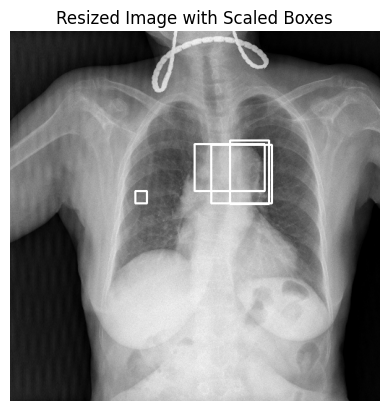

In [31]:
import cv2

img_copy = resized.copy()

for _, row in scaled_boxes.iterrows():
    x_min = int(row['x_min'])
    y_min = int(row['y_min'])
    x_max = int(row['x_max'])
    y_max = int(row['y_max'])

    cv2.rectangle(img_copy, (x_min, y_min), (x_max, y_max), (255,0,0), 2)

plt.imshow(img_copy, cmap='gray')
plt.title("Resized Image with Scaled Boxes")
plt.axis('off')
plt.show()


In [32]:
import os

labels_folder = "/kaggle/working/labels"
os.makedirs(labels_folder, exist_ok=True)


In [33]:
img_size = 512  # because you resized

for image_id in df['image_id'].unique()[:10]:  # try first 10 images
    
    boxes = df[(df['image_id'] == image_id) & (df['x_min'].notna())]
    
    if len(boxes) == 0:
        continue
    
    label_path = os.path.join(labels_folder, f"{image_id}.txt")
    
    with open(label_path, "w") as f:
        for _, row in boxes.iterrows():
            
            # scale boxes
            x_min = row['x_min'] * scale_x
            x_max = row['x_max'] * scale_x
            y_min = row['y_min'] * scale_y
            y_max = row['y_max'] * scale_y
            
            # convert to YOLO format
            x_center = ((x_min + x_max) / 2) / img_size
            y_center = ((y_min + y_max) / 2) / img_size
            width = (x_max - x_min) / img_size
            height = (y_max - y_min) / img_size
            
            class_id = int(row['class_id'])
            
            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")


In [34]:
os.listdir(labels_folder)[:5]


['051132a778e61a86eb147c7c6f564dfe.txt',
 '1c32170b4af4ce1a3030eb8167753b06.txt',
 '0c7a38f293d5f5e4846aa4ca6db4daf1.txt',
 'afb6230703512afc370f236e8fe98806.txt',
 '47ed17dcb2cbeec15182ed335a8b5a9e.txt']

In [35]:
import os

base_path = "/kaggle/working/yolo_dataset"

os.makedirs(f"{base_path}/images/train", exist_ok=True)
os.makedirs(f"{base_path}/images/val", exist_ok=True)
os.makedirs(f"{base_path}/labels/train", exist_ok=True)
os.makedirs(f"{base_path}/labels/val", exist_ok=True)


In [36]:
from sklearn.model_selection import train_test_split

image_ids = df['image_id'].unique()

train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=42)

print("Train:", len(train_ids))
print("Validation:", len(val_ids))


Train: 12000
Validation: 3000


In [37]:
import shutil

jpg_folder = "/kaggle/working/train_jpg"
labels_folder = "/kaggle/working/labels"

for image_id in train_ids:
    
    img_src = os.path.join(jpg_folder, f"{image_id}.jpg")
    lbl_src = os.path.join(labels_folder, f"{image_id}.txt")
    
    img_dst = os.path.join(base_path, "images/train", f"{image_id}.jpg")
    lbl_dst = os.path.join(base_path, "labels/train", f"{image_id}.txt")
    
    if os.path.exists(img_src):
        shutil.copy(img_src, img_dst)
        
    if os.path.exists(lbl_src):
        shutil.copy(lbl_src, lbl_dst)

# Do same for validation set
for image_id in val_ids:
    
    img_src = os.path.join(jpg_folder, f"{image_id}.jpg")
    lbl_src = os.path.join(labels_folder, f"{image_id}.txt")
    
    img_dst = os.path.join(base_path, "images/val", f"{image_id}.jpg")
    lbl_dst = os.path.join(base_path, "labels/val", f"{image_id}.txt")
    
    if os.path.exists(img_src):
        shutil.copy(img_src, img_dst)
        
    if os.path.exists(lbl_src):
        shutil.copy(lbl_src, lbl_dst)


In [38]:
yaml_content = f"""
path: {base_path}
train: images/train
val: images/val

nc: {df['class_id'].nunique()}

names: {list(df['class_name'].unique())}
"""

with open(f"{base_path}/data.yaml", "w") as f:
    f.write(yaml_content)


In [39]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.4 MB/s eta 0:00:0000:01


In [41]:
import albumentations as A
import cv2
import matplotlib.pyplot as plt

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.5)
])


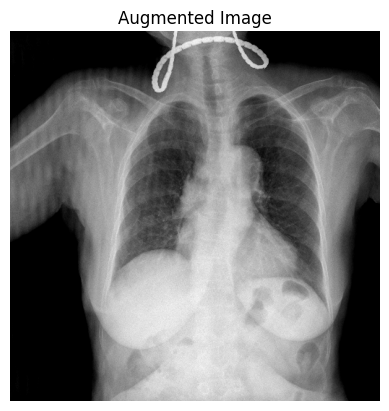

In [42]:
augmented = transform(image=resized)
aug_img = augmented['image']

plt.imshow(aug_img, cmap='gray')
plt.title("Augmented Image")
plt.axis('off')
plt.show()


In [44]:
os.listdir("/kaggle/working/yolo_dataset")


['data.yaml', 'images', 'labels']

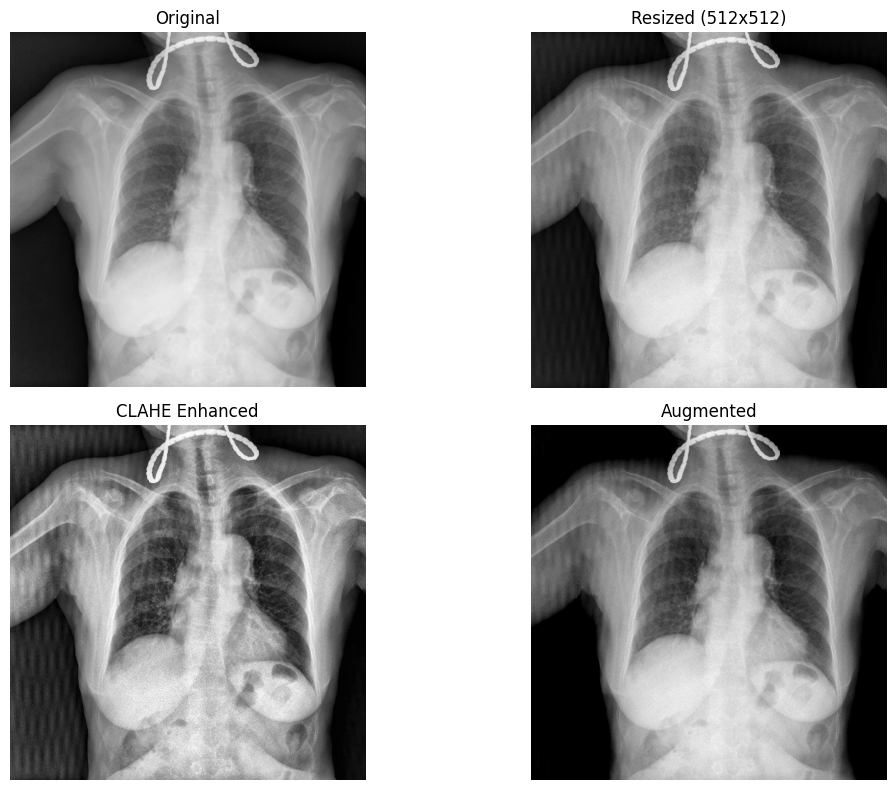

In [53]:
import matplotlib.pyplot as plt

# Make sure these exist:
# img_np (original numpy image)
# resized
# enhanced (CLAHE output)
# aug_img (augmented image)

plt.figure(figsize=(12,8))

# Original
plt.subplot(2,2,1)
plt.imshow(img_np, cmap='gray')
plt.title("Original")
plt.axis('off')

# Resized
plt.subplot(2,2,2)
plt.imshow(resized, cmap='gray')
plt.title("Resized (512x512)")
plt.axis('off')

# CLAHE Enhanced
plt.subplot(2,2,3)
plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE Enhanced")
plt.axis('off')

# Augmented
plt.subplot(2,2,4)
plt.imshow(aug_img, cmap='gray')
plt.title("Augmented")
plt.axis('off')

plt.tight_layout()
plt.show()
